In [105]:
import os
import re
from typing import Iterable

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

import datasets
from datasets import load_from_disk, concatenate_datasets

from transformers import PreTrainedTokenizerFast
from tokenizers import Tokenizer, models, trainers, normalizers, pre_tokenizers, processors, Regex

In [2]:
torch.cuda.is_available()

False

In [353]:
DATASET_PATH = os.getenv("datasetPath")
DATASET_PATH

In [351]:
DATASET_PATH = r"C:\main\GitHub\handwrittenTextRecognitionSystem\dataset"

In [5]:
main_dataset = load_from_disk(DATASET_PATH)

In [6]:
train_set = concatenate_datasets([main_dataset["train"], main_dataset["test"]])
val_set = main_dataset["valid"]
print(f"Training length: {len(train_set)}")
print(f"Validation length: {len(val_set)}")

Training length: 9397
Validation length: 976


In [415]:
class CharTokenizer:
    def __init__(self, iterable: Iterable[str]):
        self.iterable = iterable
        self.max_len = None
        self.fast_tokenizer = None
        self.tokenizer = None
    
    def get_max_len(self) -> int:
        """Returns the max length of encoded sequences"""
        assert self.fast_tokenizer != None, "Tokenizer is not trained"
        if self.max_len is None:
            the_max = 0
            for string in self.iterable:
                encoded = self.fast_tokenizer(string)["input_ids"]
                the_max = max(the_max, len(encoded))
            self.max_len = the_max
            return self.max_len
        else:
            return self.max_len

    def train(self) -> None:
        """Train tokenizer character wise"""
        tokenizer = Tokenizer(model = models.WordLevel())
        tokenizer.normalizer = normalizers.Sequence([normalizers.Lowercase(),
                                                     normalizers.Replace(Regex(r"[^a-z0-9\s]"), r""),
                                                     normalizers.Replace(Regex(r"\s+"), r" "),
                                                     normalizers.Strip()])
        
        tokenizer.pre_tokenizer = pre_tokenizers.Split(r"", "isolated", invert=True)
        tokenizer.post_processor = processors.TemplateProcessing(single=r"<sos> $0 <eos>",
                                                                 special_tokens=[(r"<sos>", 2), (r"<eos>", 3)])

        trainer = trainers.WordLevelTrainer(special_tokens=["<pad>", "<unk>", "<sos>", "<eos>"])
        tokenizer.train_from_iterator(iterator=self.iterable, trainer=trainer)

        self.tokenizer = tokenizer
        self.fast_tokenizer = PreTrainedTokenizerFast(tokenizer_object = tokenizer)
        self.fast_tokenizer.pad_token = "<pad>"

In [ ]:
class TrainDataSet(Dataset):
    def __init__(self, dataset: datasets.arrow_dataset.Dataset,
                 tokenizer: CharTokenizer):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.transforms = transforms.ToTensor()
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, indx):
        row = self.dataset[indx]
        img = self.transforms(row["image"])
        target_inds = self.tokenizer(row["text"])
        return target_inds

In [ ]:
tens = transforms.ToTensor()(train_set[1]["image"])
tens

tensor([[[0.9725, 0.9529, 0.9333,  ..., 0.9725, 0.9725, 0.9725],
         [0.9725, 0.9529, 0.9373,  ..., 0.9765, 0.9765, 0.9765],
         [0.9686, 0.9569, 0.9451,  ..., 0.9804, 0.9804, 0.9804],
         ...,
         [0.9804, 0.9765, 0.9765,  ..., 0.9843, 0.9843, 0.9843],
         [0.9843, 0.9804, 0.9765,  ..., 0.9843, 0.9843, 0.9843],
         [0.9882, 0.9804, 0.9765,  ..., 0.9843, 0.9843, 0.9843]]])

In [ ]:
tens.shape

torch.Size([1, 128, 2667])

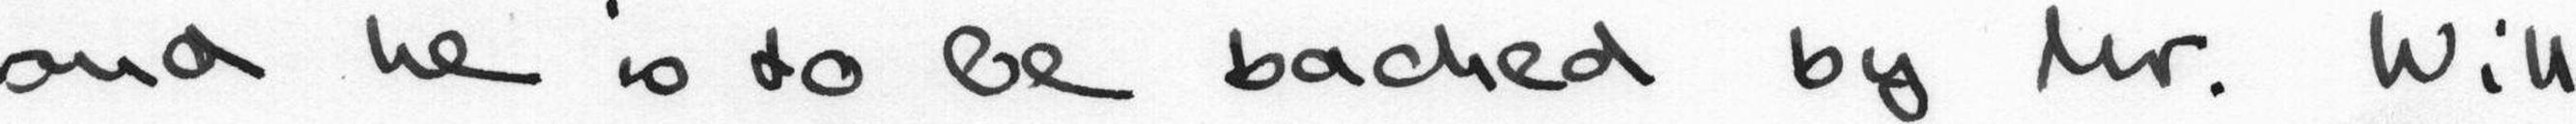

In [ ]:
transforms.functional.to_pil_image(tens)

In [ ]:
train_set[1]["text"]

'and he is to be backed by Mr. Will'

In [ ]:
main_dataset['train']

Dataset({
    features: ['text', 'image'],
    num_rows: 6482
})